In [ ]:
from __future__ import annotations
from typing import Union
import random
import math

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Optional rustworkx support
try:
    import rustworkx as rx
    RxGraph = rx.PyGraph
except ImportError:
    rx = None
    RxGraph = tuple()

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RXGate
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_aer import Aer
from qiskit import transpile

# CPLEX import
from docplex.mp.model import Model
from quantum_greedy_util import mixer_from_graph,greedy_optimize,greedy_optimize_seq_rev,greedy_optimize_seq,expectation_value_cost_shifted,expectation_value_cost_shifted_with_bitstring
from quantum_greedy_util_copy import mixer_from_graph_subset,greedy_optimize_vertex_elimination,greedy_optimize_vertex_elimination_n2,greedy_optimize_vertex_elimination_trialinthemid
from classical_heuristics_util import is_vertex_cover, local_search_vertex_cover, ga_vertex_cover,bp_vertex_cover_enforced,bp_decode_vertex_cover,bp_vertex_cover_decimation,bp_greedy_vertex_cover,greedy_optimize_classical_seq
from classical_runtime_guarantee_util import mvc_exact_cplex, mvc_lp_relaxation, greedy_degree_vertex_cover, greedy_edge_vertex_cover,mvc_primal_dual_weighted
import os
import pickle

In [ ]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt


# ----------------- Experiment Parameters -----------------
graph_sizes = [10]  # Example graph sizes
k = 20         # Number of graphs per size
degree = 3       # Edge probability for Erdos-Renyi
case = "unweighted"               # "weighted" or "unweighted"
n_stat = 1                      # Repeats for stochastic classical methods

# Seed for reproducibility
rng = np.random.default_rng(42)

# ----------------- Storage -----------------
#approaches = ["LP", "Dual-Primal", "Greedy vertex degree", "Greedy random edge", "Quantum p=1","Quantum p=2", "Quantum p=3", "Quantum p=4","Quantum p=5", "Quantum p=6"]
approaches = ["LP", "Dual-Primal", "Greedy vertex degree", "Greedy random edge", "Quantum n2 p=1","Quantum n2 p=2", "Quantum n2 p=3", "Quantum n2 p=4"]
results_mean = {appr: [] for appr in approaches}
results_std = {appr: [] for appr in approaches}

# ----------------- Experiment Loop -----------------
for n in graph_sizes:
    ratios = {appr: [] for appr in approaches}
    print(n)
    for graph_seed in range(k):
        
        #G = nx.random_regular_graph(degree,n)
        #print(G)
        #G=nx.barabasi_albert_graph(n,degree)
        #G = nx.erdos_renyi_graph(n, degree/n,seed=np.random.randint(1e9))
        while True:
            G = nx.erdos_renyi_graph(n, degree/n, seed=np.random.randint(1e9))
            if nx.is_connected(G):
                break
        G = nx.random_regular_graph(degree,n)
        # Node weights
        if case == "unweighted":
            c = {i: 1.0 for i in G.nodes()}
        else:
            c = {i: random.uniform(0.40, 0.70) for i in G.nodes()}

        # ---------------- Optimal solution ----------------
        C_opt = mvc_exact_cplex(G, c)
        opt_cost = sum(c[i] for i in C_opt)
        print(graph_seed)
        # ---------------- Classical Heuristics ----------------
        # LP relaxation
        '''
        C_lp = mvc_lp_relaxation(G, c)
        ratios["LP"].append(sum(c[i] for i in C_lp) / opt_cost)

        # Primal-dual
        C_pd = mvc_primal_dual_weighted(G, c)
        ratios["Dual-Primal"].append(sum(c[i] for i in C_pd) / opt_cost)

        # Greedy vertex degree
        C_gd = greedy_degree_vertex_cover(G, c)
        ratios["Greedy vertex degree"].append(sum(c[i] for i in C_gd) / opt_cost)

        # Greedy random edge (stochastic)
        ge_ratios = []
        for s in range(n_stat):
            run_seed = rng.integers(1e9)
            random.seed(int(run_seed))
            np.random.seed(int(run_seed))
            C_ge = greedy_edge_vertex_cover(G, c)
            ge_ratios.append(sum(c[i] for i in C_ge) / opt_cost)
        ratios["Greedy random edge"].append(np.mean(ge_ratios))
        '''

        # ---------------- Quantum Greedy ----------------
        betas = {i: np.pi/4 for i in c}  # equal betas
        strat="random"
        order="forward"
        '''
        sol_p1,E_p1 = greedy_optimize_vertex_elimination(G, c, c, betas, p=1, pick_strategy=strat, strategy=order)
        ratios["Quantum p=1"].append(E_p1 / opt_cost)
        sol_p2,E_p2 = greedy_optimize_vertex_elimination(G, c, c, betas, p=2, pick_strategy=strat, strategy=order)
        ratios["Quantum p=2"].append(E_p2 / opt_cost)
        sol_p3,E_p3 = greedy_optimize_vertex_elimination(G, c, c, betas, p=3, pick_strategy=strat, strategy=order)
        ratios["Quantum p=3"].append(E_p3 / opt_cost)
        sol_p4,E_p4 = greedy_optimize_vertex_elimination(G, c, c, betas, p=4, pick_strategy=strat, strategy=order)
        ratios["Quantum p=4"].append(E_p4 / opt_cost)
        sol_p5,E_p5 = greedy_optimize_vertex_elimination(G, c, c, betas, p=5, pick_strategy=strat, strategy=order)
        ratios["Quantum p=5"].append(E_p5 / opt_cost)
        sol_p6,E_p6 = greedy_optimize_vertex_elimination(G, c, c, betas, p=6, pick_strategy=strat, strategy=order)
        ratios["Quantum p=6"].append(E_p6 / opt_cost)
        '''
        '''
        sol_trial_p1,E_trial_p1 = greedy_optimize_vertex_elimination(G, c, c, betas, p=1, pick_strategy="random")
        ratios["Quantum trial p=1"].append(E_trial_p1 / opt_cost)
        sol_trial_p2,E_trial_p2 = greedy_optimize_vertex_elimination(G, c, c, betas, p=2, pick_strategy="random")
        ratios["Quantum trial p=2"].append(E_trial_p2 / opt_cost)
        sol_trial_p3,E_trial_p3 = greedy_optimize_vertex_elimination(G, c, c, betas, p=3, pick_strategy="random")
        ratios["Quantum trial p=3"].append(E_trial_p3 / opt_cost)
        sol_trial_p4,E_trial_p4 = greedy_optimize_vertex_elimination(G, c, c, betas, p=4, pick_strategy="random")
        ratios["Quantum trial p=4"].append(E_trial_p4 / opt_cost)
        '''
        #'''
        sol_n2_p1,E_n2_p1 = greedy_optimize_vertex_elimination_n2(G, c, c, betas, p=1)
        ratios["Quantum n2 p=1"].append(E_n2_p1 / opt_cost)
        sol_n2_p2,E_n2_p2 = greedy_optimize_vertex_elimination_n2(G, c, c, betas, p=2)
        ratios["Quantum n2 p=2"].append(E_n2_p2 / opt_cost)
        sol_n2_p3,E_n2_p3 = greedy_optimize_vertex_elimination_n2(G, c, c, betas, p=3)
        ratios["Quantum n2 p=3"].append(E_n2_p3 / opt_cost)
        sol_n2_p4,E_n2_p4 = greedy_optimize_vertex_elimination_n2(G, c, c, betas, p=4)
        ratios["Quantum n2 p=4"].append(E_n2_p4 / opt_cost)
        #'''
        '''
        marginals = bp_vertex_cover_decimation(G,c,beta=10.0,max_bp_iter=1000,damping=0.3,seed=42)
        #print(marginals)
        #C = bp_decode_vertex_cover(G, marginals)
        C=marginals
        ratios["BP"].append(sum(c[i] for i in C)/opt_cost)
        '''

    # ---------------- Compute mean & std ----------------
    for appr in approaches:
        results_mean[appr].append(np.mean(ratios[appr]))
        results_std[appr].append(np.std(ratios[appr]))




10
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


c:\Users\rubenb\OneDrive - SINTEF\Desktop\Min_vertex_anal\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\rubenb\OneDrive - SINTEF\Desktop\Min_vertex_anal\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\rubenb\OneDrive - SINTEF\Desktop\Min_vertex_anal\.venv\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\rubenb\OneDrive - SINTEF\Desktop\Min_vertex_anal\.venv\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\rubenb\OneDrive - SINTEF\Desktop\Min_vertex_anal\.venv\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered

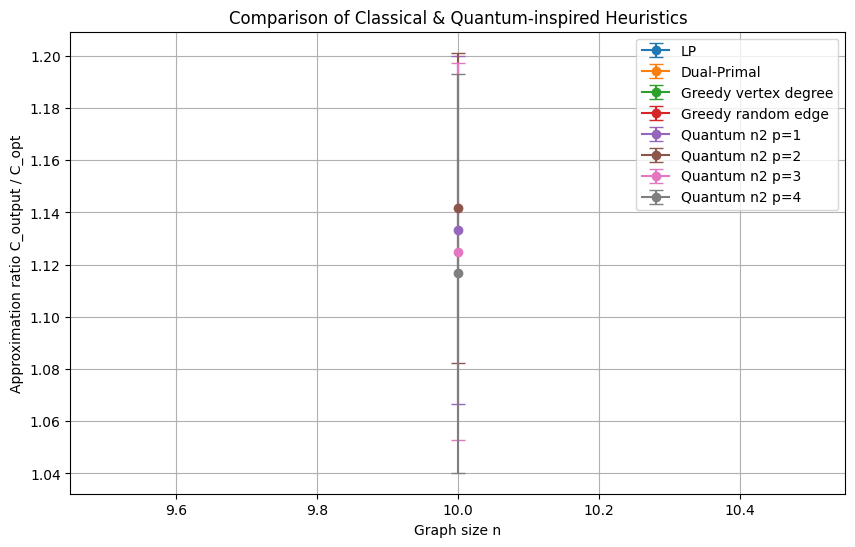

In [ ]:
# ----------------- Plotting -----------------
plt.figure(figsize=(10,6))
for appr in approaches:
    plt.errorbar(graph_sizes, results_mean[appr], yerr=results_std[appr], marker='o', label=appr, capsize=5)
plt.xlabel("Graph size n")
plt.ylabel("Approximation ratio C_output / C_opt")
plt.title("Comparison of Classical & Quantum-inspired Heuristics")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
for appr in approaches: 
    print(appr,results_mean[appr])
    print(appr,results_std[appr])

LP [np.float64(nan)]
LP [np.float64(nan)]
Dual-Primal [np.float64(nan)]
Dual-Primal [np.float64(nan)]
Greedy vertex degree [np.float64(nan)]
Greedy vertex degree [np.float64(nan)]
Greedy random edge [np.float64(nan)]
Greedy random edge [np.float64(nan)]
Quantum n2 p=1 [np.float64(1.1333333333333333)]
Quantum n2 p=1 [np.float64(0.06666666666666661)]
Quantum n2 p=2 [np.float64(1.1416666666666662)]
Quantum n2 p=2 [np.float64(0.059511903571190364)]
Quantum n2 p=3 [np.float64(1.1249999999999993)]
Quantum n2 p=3 [np.float64(0.0721687836487031)]
Quantum n2 p=4 [np.float64(1.1166666666666671)]
Quantum n2 p=4 [np.float64(0.07637626158259747)]
